## Initial testing
just getting some plots and basic analysis for the initial data we have

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [94]:
freq = 175
savename = "Mar 9 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/NewFile' + str(freq) + 'kHz' + '.csv')
# time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 9 measurement/NewFile175kHz.csv')

bAdjustment =  1 #1.03360784475 # 1.07555537208

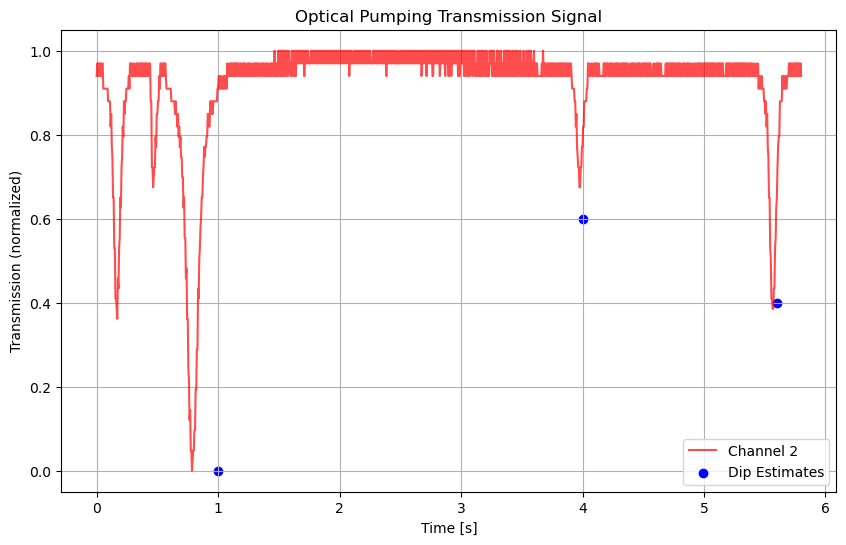

In [95]:
t0 = 0
tf = 5.8
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]


x0s = np.array([1,4,5.6])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)


A 0.9592203664547313
h1 0.9570941248049117
g1 0.0534343687987262
x0_1 0.7898961446250596
h2 0.2833488170633836
g2 0.02558500879445717
x0_2 3.9777376474775594
h3 0.6032763462460097
g3 0.028486859108895715
x0_3 5.567224068189268


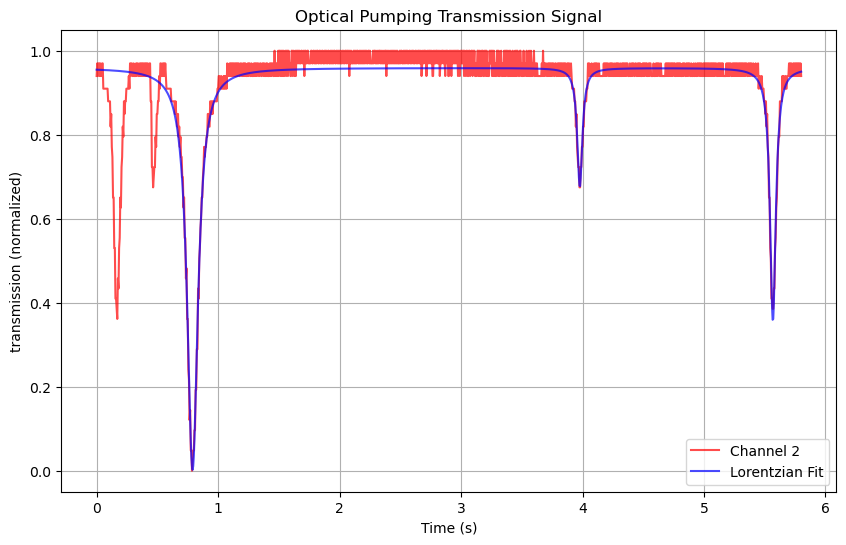

In [96]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.triple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.triple_lorentz, "fit to " + savename)


In [97]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0
x0_3_u = ufloat(popt[9], perr[9]) + t0

# 3. Handle indexing (indices must be integers, so we use n)
dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)

numAvg = 10

# 4. Calculate mean voltages (V) with uncertainty
# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]))

# 5. Define calibration constant
# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
# VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4)/100) * bAdjustment/10 # this factor of 10 is only for measurements up to and including Mar 9
VtoB = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd


Rb_87 = (v_2 - v_1) * VtoB
Rb_85 = (v_3 - v_1) * VtoB

print(f"v_1: {v_1/10:.3e} V")

print(f"Rb87: {Rb_87:.3e} T")
print(f"Rb85: {Rb_85:.3e} T")

v_1: (2.924+/-0.071)e-02 V
Rb87: (2.503+/-0.062)e-05 T
Rb85: (3.745+/-0.074)e-05 T


In [78]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)

In [71]:
freq = 500
vHoriz = 40.4 # mV
savename = "5s measurement Mar 23 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 23 measurement/' + str(freq) + 'kHz_' + str(vHoriz).replace('.', 'p') + 'mV.csv')
vHoriz = vHoriz/1000


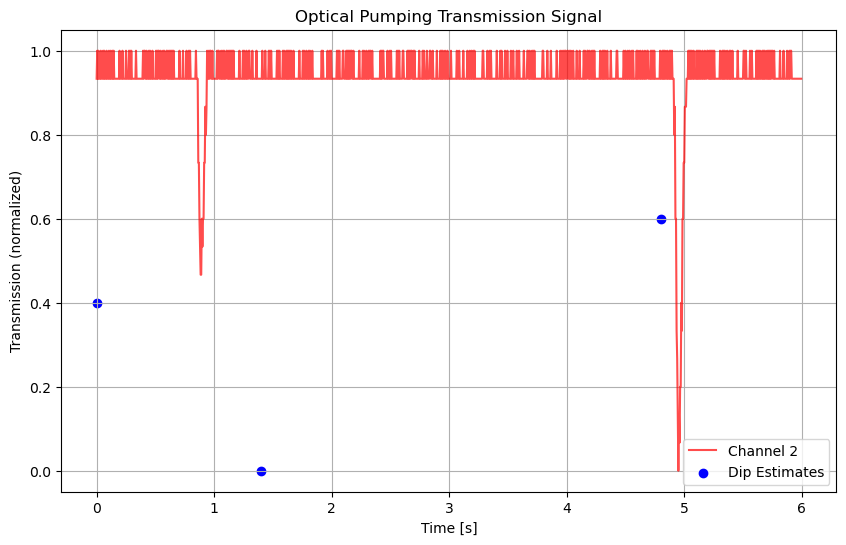

In [72]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([1.4,4.8,0])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)


In [73]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1])
lower_bound = (0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.double_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9532891931875501
h1 0.5009854079399018
g1 0.018353779493868527
x0_1 0.8911893275773768
h2 0.9697994164074769
g2 0.020528676969732762
x0_2 4.956235904587143


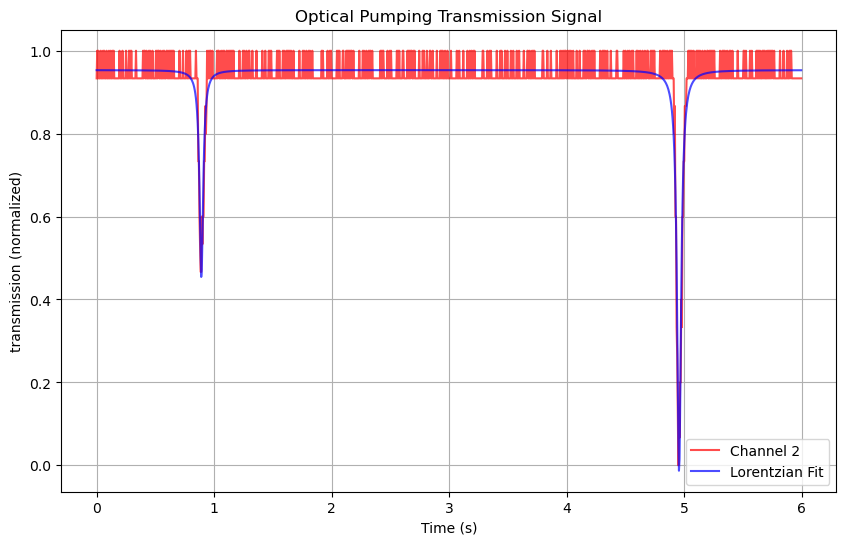

In [74]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.double_lorentz, "fit to " + savename)

In [75]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))


v_0 = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
# VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4) / 100) * bAdjustment
VtoB = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd
# VtoBHoriz = ufloat(1.705174,0.028108) / 1000
# VtoBHoriz = ufloat(1.775151,0.029249) / 1000
# VtoBHoriz = ufloat(1.730183,0.033567) / 1000 # from mar23
# VtoBHoriz = VtoB * ufloat(27.731,0.047) # new from Mar25 # TODO: i switched from 27.731 which is the actual number
VtoBHoriz = ufloat(1.7326589,0.0112084) / 10**3 # new from Mar27

print(f"VtoBHoriz: {VtoBHoriz:.3e} T")

Rb_87 = (v_1 - v_0) * VtoB + vHoriz * VtoBHoriz
Rb_85 = (v_2 - v_0) * VtoB + vHoriz * VtoBHoriz

# print(f"v_0: {v_0:.3e} V")

print(f"Rb87: {Rb_87:.3e} T")
print(f"Rb85: {Rb_85:.3e} T")

VtoBHoriz: (1.734+/-0.010)e-03 T
Rb87: (7.126+/-0.063)e-05 T
Rb85: (1.071+/-0.009)e-04 T


In [76]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)

In [28]:
freq = 700
vHoriz = 0.043
savename = "5s measurement Mar 20 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 20 measurement/' + str(freq) + 'kHz_5s_.csv')



FileNotFoundError: [Errno 2] No such file or directory: './data/Mar 23 measurement/700kHz_5s_.csv'

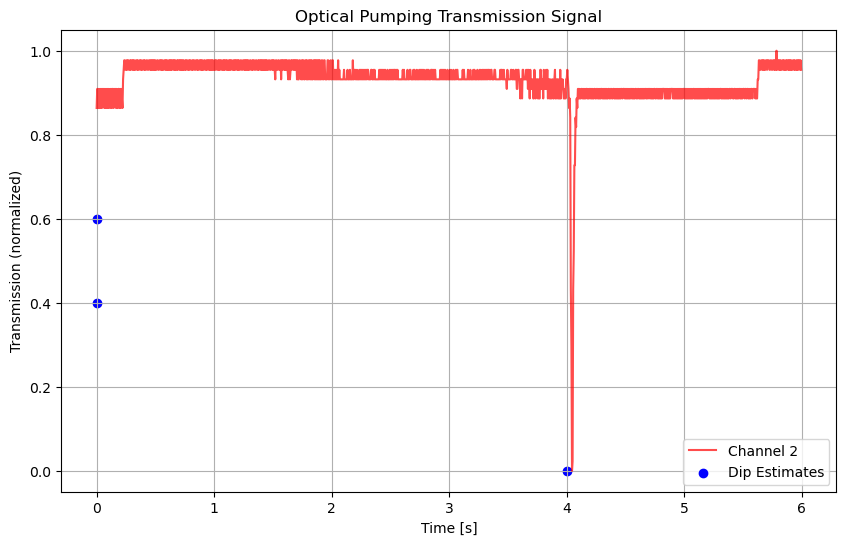

In [240]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([4,0,0])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)


In [241]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1"]
p0 = (1, 1, 0.3, x0s[0])
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9351786247228147
h1 0.9871642042997023
g1 0.009417692033962302
x0_1 4.047010901717838


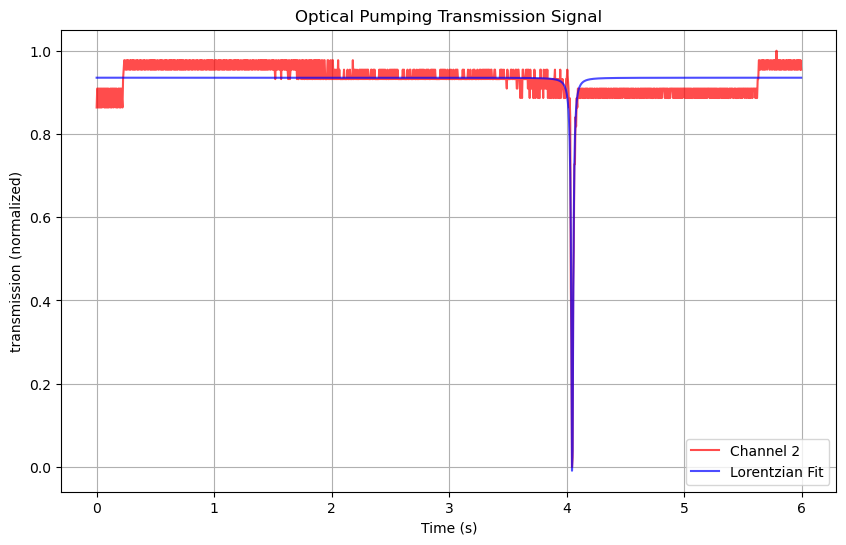

In [242]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [243]:
x0_1_u = ufloat(popt[3], perr[3]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)
v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]))


v_0 = ufloat(0.3,0.0034) # taken from 25kHz, though other frequencies were close (this isn't frequency dependent)

# Note: if there is uncertainty in the 0.6 factor, you should make it a ufloat too
# VtoB = ufloat(0.6 * 10**(-4),0.6 * 10**(-4) / 100) * bAdjustment
VtoB = ufloat(6.20693,0.03559)*10**(-5) # new VtoB from Mar 23rd
# VtoBHoriz = ufloat(1.705174,0.028108) / 1000
# VtoBHoriz = ufloat(1.775151,0.029249) / 1000
# VtoBHoriz = ufloat(1.730183,0.033567) / 1000 # from mar23
# VtoBHoriz = VtoBSweep * ufloat(27.731,0.047) # new from Mar25
VtoBHoriz = ufloat(1.7326589,0.0112084) / 10**3 # new from Mar27

print(f"VtoBHoriz: {VtoBHoriz} T")

Rb_87 = (v_1 - v_0) * VtoB + vHoriz * VtoBHoriz

print(f"Rb87: {Rb_87:.3e} T")

Rb87: (9.738+/-0.182)e-05 T


In [244]:
vHoriz = 0.072
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 20 measurement/' + str(freq) + 'kHz_5s_72.csv')

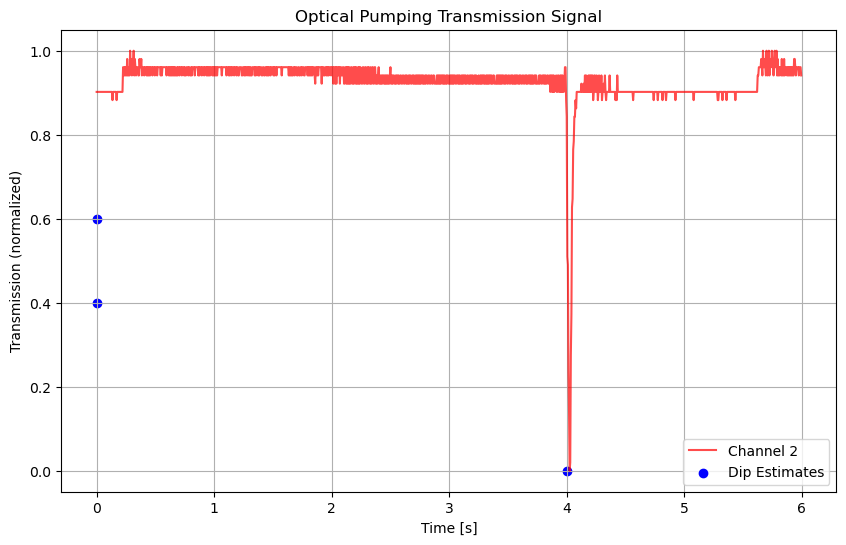

In [245]:
t0 = 0
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([4,0,0])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [246]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1"]
p0 = (1, 1, 0.3, x0s[0])
lower_bound = (0,0,0,0)
upper_bound = (2,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.single_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
# popt, pcov = curve_fit(multi_lorentz, x, y2)
# print(popt)
for val, name in zip(popt,variables):
    print(name, val)

A 0.9335764985880388
h1 0.9799134737086443
g1 0.01367149688510399
x0_1 4.026022809459111


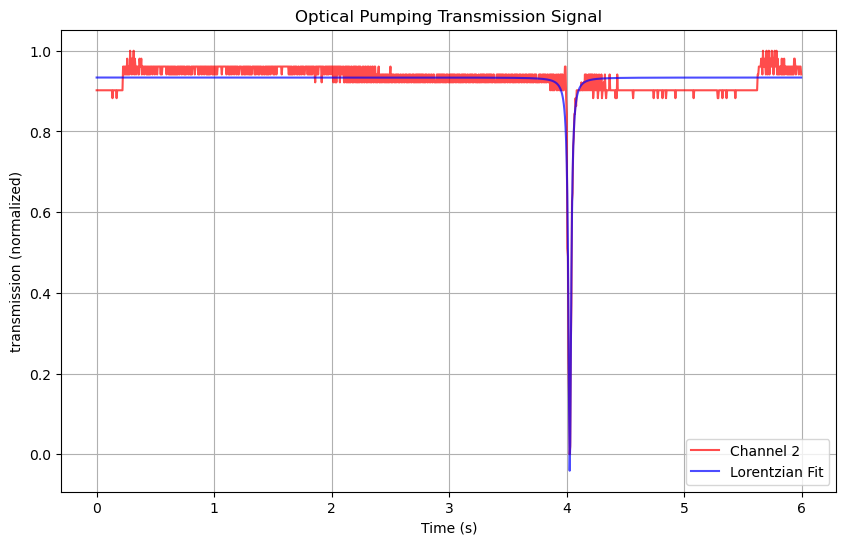

In [247]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.single_lorentz, "fit to " + savename)

In [248]:
x0_2_u = ufloat(popt[3], perr[3]) + t0

x0_2_index = int(x0_2_u.n // dt)

numAvg = 10

# We treat the raw data y1 as having some inherent noise (e.g., std dev of the mean)

v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]))


Rb_85 = (v_2 - v_0) * VtoB + vHoriz * VtoBHoriz

print(f"Rb85: {Rb_85:.3e} T")

Rb85: (1.469+/-0.023)e-04 T


In [249]:
filepath = 'models/BFreqRatiosUncertain.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)